# Amazon Ads Analytics — Business Analysis

Walkthrough of the SQL warehouse. Each section runs one analytical query
against the warehouse, shows results, charts them, and discusses what
they mean operationally.

**Data context:** four Amazon marketplace reports for a single brand
("Brand_A") over a ~one-month window, anonymized programmatically.


## Setup

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)

DB = Path("../data/warehouse.db")
QUERIES = Path("../sql/queries")

conn = sqlite3.connect(DB)

def run(sql_file):
    sql = (QUERIES / sql_file).read_text()
    return pd.read_sql_query(sql, conn)


### Warehouse sanity check

In [2]:
for table in ["dim_date", "dim_campaign", "dim_product",
              "fact_ads_daily", "fact_search_term", "fact_business_report"]:
    n = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table:<25} {n:>7,} rows")


  dim_date                       28 rows
  dim_campaign                  600 rows
  dim_product                   111 rows
  fact_ads_daily              1,110 rows
  fact_search_term            2,705 rows
  fact_business_report           66 rows


## Q1 — Campaign ROAS with TACoS context

**Question:** which campaigns are most efficient on their own ROAS, and how do
they look against TOTAL business sales (TACoS lens)?

**Why it matters:** a campaign can have great ROAS in isolation but
contribute a tiny share of business sales. Looking at both lenses
prevents over-celebrating small efficient campaigns at the expense of
portfolio decisions.


In [3]:
q1 = run("01_campaign_roas_tacos.sql")
print(f"Campaigns analyzed: {len(q1):,}")
q1.head(10)


Campaigns analyzed: 252


,campaign_name,portfolio_name,targeting_type,spend,ad_sales,orders,roas,acos,tacos
0,BR | SP | Exact | Harvesting Nov | ASIN_C310A2...,NaN,Manual,0.45,29.99,1,66.64,0.01,0.00
1,Krill Oil | SP 3 | Dwn | EC,Omega Krill Oil,Manual,0.99,54.99,1,55.55,0.02,0.00
2,e252f968105b6b97d775089c221b003d,NaN,Manual,0.70,35.99,1,51.41,0.02,0.00
3,Brand_A_Product_2 | SP 3 | Dwn | Perpetu,Brand_A_Product_2,Manual,0.52,24.99,1,48.06,0.02,0.00
4,Brand_A_Product_1 Branded - Perpetua - SP - Au...,Growing Products,Auto,2.53,75.97,3,30.03,0.03,0.00
5,BR | SP | Exact | Harvesting Nov | ASIN_1A1A7E...,NaN,Manual,1.25,36.99,1,29.59,0.03,0.00
6,Brand_A_Product_VM | Impression Share | SP P | EC,Brand_A_Product_VM,Manual,1.11,29.99,1,27.02,0.04,0.00
7,Resveratrol | SP 3 | Dwn | EC,Resveratrol,Manual,1.98,51.99,1,26.26,0.04,0.00
8,5efbe04b7971fffbee7bebf9e27388c8,NaN,Manual,1.23,24.99,1,20.32,0.05,0.00
9,bb8dd83921dd68ad16c90b80ed192187,NaN,Manual,1.23,23.99,1,19.50,0.05,0.00


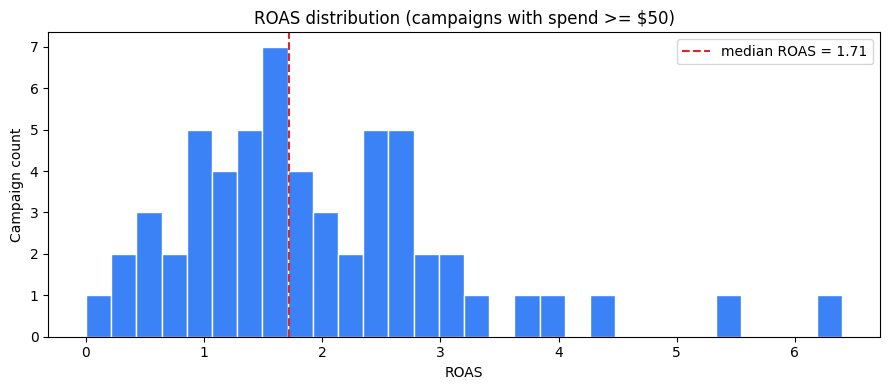

In [4]:
active = q1[q1["spend"] >= 50].copy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(active["roas"], bins=30, color="#3B82F6", edgecolor="white")
ax.axvline(active["roas"].median(), color="#DC2626", linestyle="--",
           label=f"median ROAS = {active['roas'].median():.2f}")
ax.set_xlabel("ROAS")
ax.set_ylabel("Campaign count")
ax.set_title("ROAS distribution (campaigns with spend >= $50)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation (fill in based on results):**

- Top performing campaigns by ROAS: _list 2-3_
- Portfolio-level TACoS: _X%_. Under 15% is generally healthy.
- _Add observations on which campaigns are over- or under-funded._


## Q2 — Harvestable search terms

**Question:** which broad/auto search terms have converted profitably
and should be promoted to exact-match campaigns?

**Why it matters:** keyword harvesting is one of the highest-ROI
activities in Amazon Ads management.


In [5]:
q2 = run("02_harvestable_search_terms.sql")
print(f"Harvestable terms: {len(q2):,}")
q2.head(15)


Harvestable terms: 33


,customer_search_term,campaign_name,targeting_type,match_type,impressions,clicks,spend,sales,orders,roas,acos,conversion_rate,rank_in_campaign
0,500 mg extended release niacin,9610660c372717d32c2b06d1f80a1c7b,Manual,BROAD,7,6,19.07,89.97,3,4.72,0.21,0.50,1
1,niacin extended release 500 mg,9610660c372717d32c2b06d1f80a1c7b,Manual,BROAD,13,5,16.34,59.98,2,3.67,0.27,0.40,3
2,Brand_A dihydroberberine,BR | SP | Broad | ASIN_A59C0CA0 | Dihydroberbe...,Manual,BROAD,200,16,21.71,227.96,4,10.50,0.10,0.25,1
3,Brand_A dihydroberberine supplement,BR | SP | Broad | ASIN_A59C0CA0 | Dihydroberbe...,Manual,BROAD,14,3,5.71,177.98,2,31.17,0.03,0.67,2
4,Brand_A_Product_1,BR | SP | Mix Match Type | ASIN_5BECFEF0 | Nia...,Manual,BROAD,644,21,10.00,351.86,13,35.19,0.03,0.62,1
5,Brand_A_Product_1 500mg extended release niaci...,BR | SP | Mix Match Type | ASIN_5BECFEF0 | Nia...,Manual,BROAD,520,11,17.67,229.91,7,13.01,0.08,0.64,2
6,Brand_A_Product_1 250mg,BR | SP | Mix Match Type | ASIN_5BECFEF0 | Nia...,Manual,BROAD,735,15,41.22,176.93,5,4.29,0.23,0.33,3
7,Brand_A_Product_1 500,BR | SP | Mix Match Type | ASIN_5BECFEF0 | Nia...,Manual,BROAD,18,2,0.80,119.96,2,149.95,0.01,1.00,5
8,Brand_A_Product_1,BR | SP | Mix Match Type | All ASINs | Brand_A...,Manual,BROAD,2,1,3.80,89.97,2,23.68,0.04,2.00,1
9,Brand_A_Product_1 750mg,BR | SP | Mix Match Type | Mix ASINs | Brand_A...,Manual,BROAD,26,4,1.85,167.96,4,90.79,0.01,1.00,1


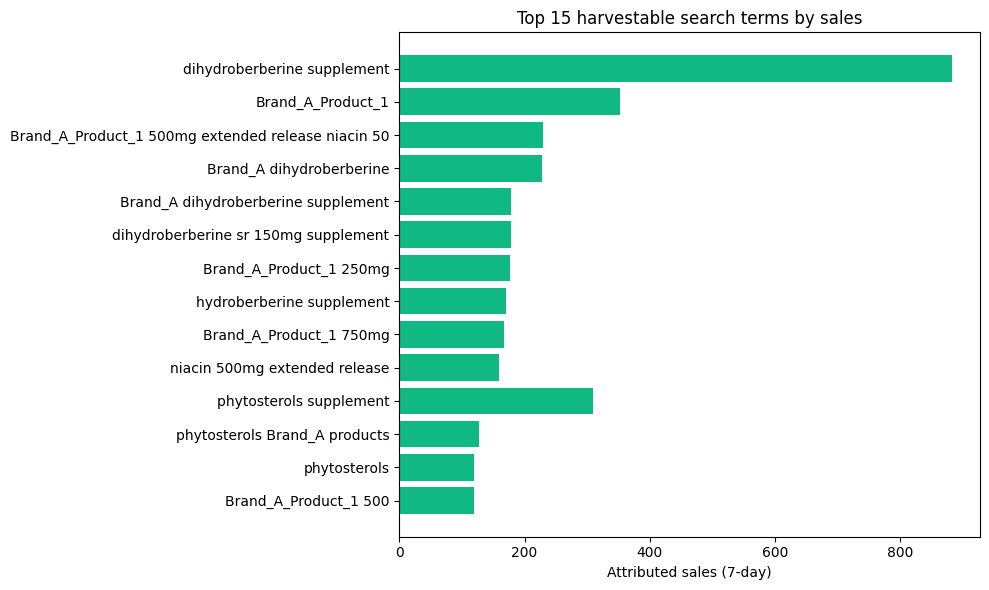

In [6]:
if len(q2) > 0:
    top = q2.nlargest(15, "sales").iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top["customer_search_term"].str[:50], top["sales"], color="#10B981")
    ax.set_xlabel("Attributed sales (7-day)")
    ax.set_title("Top 15 harvestable search terms by sales")
    plt.tight_layout()
    plt.show()
else:
    print("No harvestable terms found with current thresholds.")


**Interpretation:**

- _Which terms surprised you?_
- _Which would you promote first?_


## Q3 — Wasted spend detection

**Question:** which search terms eat budget without converting?
Candidates for negative keywords.


In [7]:
q3 = run("03_wasted_spend.sql")
print(f"Wasted-spend candidates: {len(q3):,}")
print(f"Total wasted spend: ${q3['spend'].sum():,.2f}")
q3.head(15)


Wasted-spend candidates: 12
Total wasted spend: $1,027.39


,waste_reason,customer_search_term,campaign_name,targeting_type,clicks,spend,sales,orders,acos
0,no_conversions,l arginine,BR | SP | Mix Match | Harvesting | Mix ASINs |...,Manual,32,172.59,0.00,0,NaN
1,unprofitable,arginine supplement,BR | SP | Mix Match | Harvesting | Mix ASINs |...,Manual,24,134.62,36.99,1,3.64
2,unprofitable,niacin 500mg,NB | SP | Mix Match | Harvesting Dec | ASIN_C3...,Manual,30,105.12,89.97,3,1.17
3,unprofitable,niacin 500mg,NB | SP | Mix Match | Mix ASINs | Good Perform...,Manual,35,102.21,85.96,3,1.19
4,unprofitable,Brand_A_Product_1 250mg,NB | SP | Exact | Mix ASINs | Brand_A_Product_...,Manual,16,101.76,91.97,3,1.11
5,unprofitable,niacin,NB | SP | Mix Match | Mix ASINs | Good Perform...,Manual,31,97.68,63.96,4,1.53
6,unprofitable,b014831ics,NB | SP | Defensive | All ASINs | AMZ,Manual,37,72.86,59.98,2,1.21
7,no_conversions,vitamin b3 for men,NB | SP | Exact | Harvesting Nov | ASIN_C310A2...,Manual,17,56.16,0.00,0,NaN
8,unprofitable,vitamin b3,181a180c32f48117b198e49490d3ff3e,Manual,19,53.11,29.99,1,1.77
9,unprofitable,niacin,NB | SP | Mix Match | ASIN_8E46938B | Plain Ni...,Manual,17,49.53,29.99,1,1.65


In [8]:
if len(q3) > 0:
    by_reason = q3.groupby("waste_reason")["spend"].agg(["sum", "count"]).sort_values("sum", ascending=False)
    by_reason.columns = ["total_spend", "n_search_terms"]
    print(by_reason)


                total_spend  n_search_terms
waste_reason                               
unprofitable         752.92               9
no_conversions       274.47               3


**Interpretation:**

- _Total wasted: $X over the period_
- _Most common waste reason: ..._
- _Specific search terms to negativize now: ..._


## Q4 — Ads vs organic synergy at the ASIN level

**Question:** what share of sales is ads vs organic per product?

**Why it matters:** foundational view for marketing-mix thinking on Amazon.


In [9]:
q4 = run("04_ads_vs_organic_synergy.sql")
print(f"ASINs analyzed: {len(q4):,}")
q4.head(15)


ASINs analyzed: 34


,asin,title_short,total_sales,ad_sales,organic_sales,ad_spend,sessions,avg_conversion_pct,ad_sales_share,tacos_asin,health_label
0,Parent_ASIN_c310a2a859,Brand_A Products Brand_A_Product_1 Niacin - Vi...,62319.22,0.00,62319.22,0.00,4217,0.49,0.00,0.00,no_ads
1,Parent_ASIN_a59c0ca0e6,Brand_A Products Dihydroberberine - Sustained ...,34774.92,0.00,34774.92,0.00,2138,0.24,0.00,0.00,no_ads
2,Parent_ASIN_010102efff,Zinc - Brand_A_Product_3GI 75mg for Immune Fun...,14327.48,0.00,14327.48,0.00,1447,0.41,0.00,0.00,no_ads
3,Parent_ASIN_1577f5e1cc,Brand_A Products VITAMIN,13823.28,0.00,13823.28,0.00,1135,0.61,0.00,0.00,no_ads
4,Parent_ASIN_1fdf6af8a7,"Brand_A Products, Brand_A_Product_1 - Extended...",11044.24,0.00,11044.24,0.00,564,0.47,0.00,0.00,no_ads
5,Parent_ASIN_6398c06599,Brand_A Products EP Plain Niacin Immediate Rel...,10882.63,0.00,10882.63,0.00,1211,0.45,0.00,0.00,no_ads
6,Parent_ASIN_8e46938b55,Brand_A Products Plain Niacin - 250mg Immediat...,6092.19,0.00,6092.19,0.00,1139,0.33,0.00,0.00,no_ads
7,Parent_ASIN_c21602fe73,"Phytosterols, Immediate Release, Plant-Sourced...",4118.96,0.00,4118.96,0.00,507,0.21,0.00,0.00,no_ads
8,Parent_ASIN_1c0e79566b,Brand_A Products 300 mg Pantethine from Pantes...,3855.93,0.00,3855.93,0.00,289,0.37,0.00,0.00,no_ads
9,Parent_ASIN_d157c1f9a5,"Brand_A Products Taxifolin - Vitamin C, Zinc, ...",2124.05,0.00,2124.05,0.00,122,0.29,0.00,0.00,no_ads


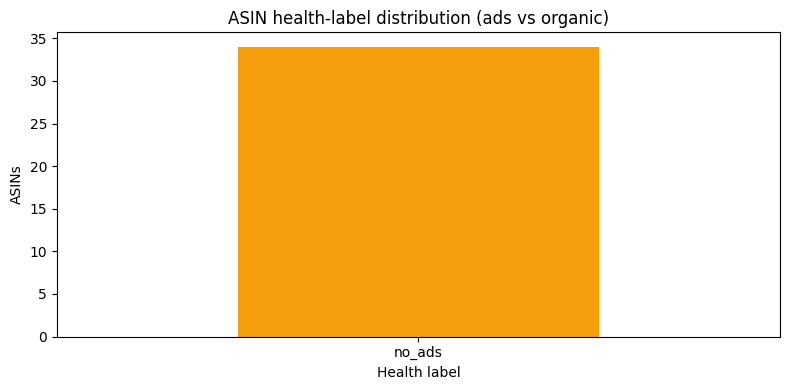

health_label
no_ads    34
Name: count, dtype: int64


In [10]:
if len(q4) > 0:
    health_dist = q4["health_label"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    health_dist.plot(kind="bar", color="#F59E0B", ax=ax)
    ax.set_title("ASIN health-label distribution (ads vs organic)")
    ax.set_xlabel("Health label")
    ax.set_ylabel("ASINs")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(health_dist)


**Interpretation & data quality note:**

> **Observed mismatch:** Business Report uses Parent ASINs while
> Advertised Product Report uses Child ASINs. Some ASINs show "no_ads"
> when they actually are advertised. In production, fix with a
> parent-child ASIN dimension from Amazon's catalog.

- _Which products are most ad-dependent?_
- _Which have strong organic and could reduce ad spend?_


## Q5 — Daily trend with rolling averages

**Question:** is portfolio performance trending up, down, or stable?
Where are the inflection points?


In [11]:
q5 = run("05_daily_trend_anomalies.sql")
q5["date_id"] = pd.to_datetime(q5["date_id"])
print(f"Days analyzed: {len(q5)}")
q5.head()


Days analyzed: 28


,date_id,daily_spend,rolling_7d_spend,daily_sales,daily_orders,daily_roas,rolling_7d_roas,spend_one_week_ago,spend_wow_change,anomaly_flag
0,2025-02-01,21014.03,21014.03,41678.99,1394,1.98,1.98,NaN,NaN,NaN
1,2025-02-02,65.42,10539.72,55.97,2,0.86,1.42,NaN,NaN,NaN
2,2025-02-03,13.82,7031.09,29.99,1,2.17,1.67,NaN,NaN,NaN
3,2025-02-04,3.86,5274.28,0.00,0,0.00,1.25,NaN,NaN,roas_anomaly
4,2025-02-05,1.23,4219.67,23.99,1,19.50,4.90,NaN,NaN,roas_anomaly


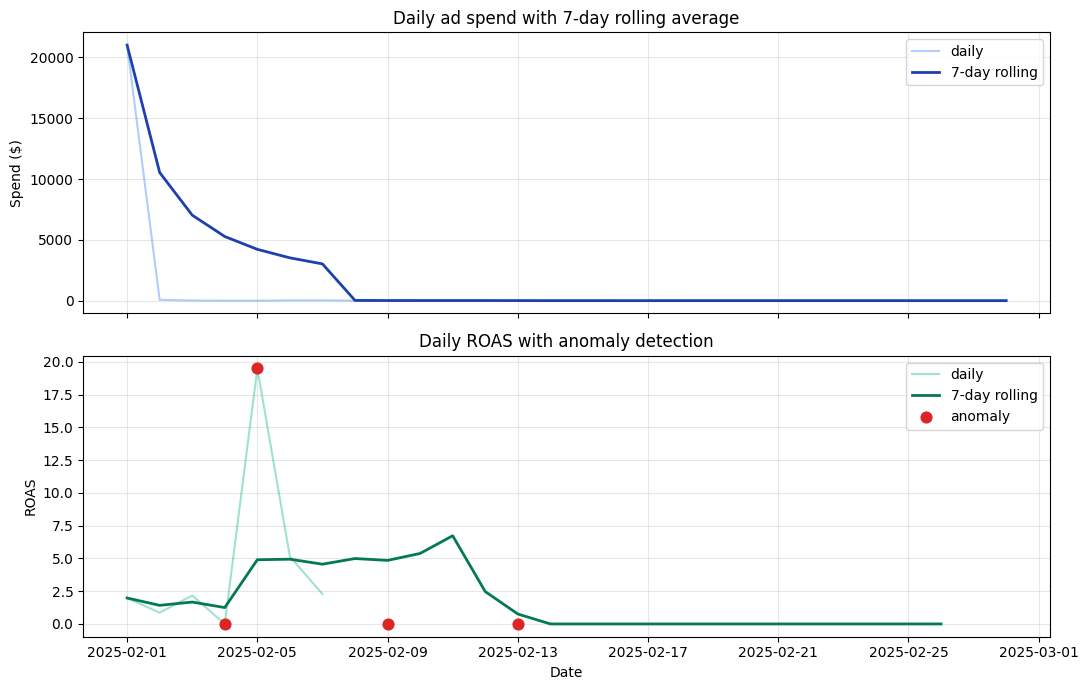

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(q5["date_id"], q5["daily_spend"], color="#3B82F6", alpha=0.4, label="daily")
ax1.plot(q5["date_id"], q5["rolling_7d_spend"], color="#1E40AF", linewidth=2, label="7-day rolling")
ax1.set_ylabel("Spend ($)")
ax1.set_title("Daily ad spend with 7-day rolling average")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(q5["date_id"], q5["daily_roas"], color="#10B981", alpha=0.4, label="daily")
ax2.plot(q5["date_id"], q5["rolling_7d_roas"], color="#047857", linewidth=2, label="7-day rolling")
anomalies = q5[q5["anomaly_flag"] == "roas_anomaly"]
if len(anomalies) > 0:
    ax2.scatter(anomalies["date_id"], anomalies["daily_roas"],
                color="#DC2626", s=60, zorder=5, label="anomaly")
ax2.set_ylabel("ROAS")
ax2.set_xlabel("Date")
ax2.set_title("Daily ROAS with anomaly detection")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Interpretation:**

- _Trend over the window: ..._
- _Anomaly days observed: ..._
- _Probable causes to investigate: ..._


## Summary & data quality observations

**Pipeline outputs:**
1. Portfolio ROAS / TACoS overview (Q1)
2. Harvestable search terms ready for promotion (Q2)
3. Wasted-spend candidates for negative keywords (Q3)
4. Per-ASIN ads-vs-organic health labels (Q4)
5. Daily monitoring with anomaly flags (Q5)

**Data quality issues encountered:**
- **ASIN granularity mismatch:** Business Report uses Parent ASINs, Advertised
  Product Report uses Child ASINs. Joining them directly under-reports ad
  contribution.
- **Reporting window heterogeneity:** Business Report is a snapshot,
  ad reports are daily.
- **Currency formatting:** dollar strings with `$` and commas need cleaning
  before numeric coercion.

**Improvements for v2:**
- Wire orchestration (Prefect or Airflow) for daily runs.
- Add Great Expectations checks to fail loudly on schema or value drift.
- Add a parent-child ASIN dimension to resolve the ads-vs-organic join.
- Migrate from SQLite to a managed warehouse if scale grows.


In [13]:
conn.close()